# Множественная проверка гипотез 

> Пусть проверяем m гипотез.    
Вероятность получить хотя бы одну ошибку первого рода FWER (Family-wise Error Rate):
$$\text{FWER} = P(FP > 0) = 1 - (1 - \alpha)^m \text{ (аналог уровня значимости)}$$

Получается, что реальный уровень значимости будет ниже $\alpha$ при росте $m$. На самом деле, если мы значем, что в эксперименте равно $m_0$ гипотез без эффекта, то в формуле лучше использовать $m_0$. И чем оно больше, тем больше $FWER$ (это видно по графикам).

Еще некоторые метрики:  

$$\text{FDR} = \text{Precision} = \frac{\text{False Positive}}{\text{TP + FP}} \text{ (другой аналог уровня значимости)}$$

*В общем случае $FWER$ на заданном уровне значимости дает меньше False Positive результатов, чем $FDR$*

$$\text{Power} = \text{Recall} =  \frac{\text{True Positive}}{\text{Total True}} \text{ (аналог мощности)}$$

---

Теперь другая логика. Мы вообще не смотрим на p-value. Мы просто берем 100 вариантов, измеряем их средние значения и выбираем тот вариант, где **точечная оценка (число) выше всего**.

> Какая вероятность выбрать неверную гипотезу? 

Мы совершим ошибку (выберем неверную гипотезу), если хотя бы одна из «пустых» гипотез случайно покажет результат больше, чем реальная:
$$P(\text{ошибка}) = P(max(\hat{\theta_2}, ... , \hat{\theta_m}) > \hat{\theta_1})$$

Чтобы найти эту вероятность, нужно вычислить вероятность того, что все $m - 1$
пустых гипотез окажутся меньше, чем конкретное значение $\hat{\theta_1}$, и проинтегрировать это по всем возможным значениям $\hat{\theta_1}$

$$P(\text{ошибка}) = 1 - P(\text{успех}) = \int_{-\infty}^{+\infty}\left[F_0(x)\right]^{m-1}\,f_1(x)\,dx$$

------

Основные методы (контролируютна уровне значимости $\alpha$):
- **Метод Бонферрони** (контролирует $FWER$). Для каждой гипотезы задаем уровень значимости $\alpha/m$
- **Метод Холма** (контролирует $FWER$). Упорядочим по pvalue и последовательно задаем уровень значимости $\alpha / (m - i + 1)$
- **Метод Бенджамини-Хохберга** (контролирует $FDR$). Похожий на метод Холма, но используются $\alpha * i / m$

-----

**Как уменьшить число пользователей в тестовой группе при множественном тестировании?**

Ранее для каждой тестовой группы мы брали свою контрольную  

Но можно взять общую большую контрольную группу для всех тестовых, чтобы сократить количество пользователей в тестовой группе

Какой выбрать размер групп, чтобы мощность сохранилась на желаемом уровне? Вспомним формулу, связывающую параметры критерия:

$$
\varepsilon^2
=
\left[\Phi^{-1}\!\left(1-\frac{\alpha}{2}\right)+\Phi^{-1}(1-\beta)\right]^2
\left(\frac{\sigma_A^2}{n_A}+\frac{\sigma_B^2}{n_B}\right)
$$

Проверяем $m$ гипотез с объединённой контрольной группой. Положим $n_A = nm$, $n_B = n$ и $\sigma=\sigma_A=\sigma_B$, тогда

$$
n
=
\frac{m+1}{m}\cdot\frac{\sigma^2}{\varepsilon^2}
\left[\Phi^{-1}\!\left(1-\frac{\alpha}{2}\right)+\Phi^{-1}(1-\beta)\right]^2
$$

При $m=1$ получаем $(m+1)/m=2$, а при $m=100$ получаем $(m+1)/m=1.01$.
Ранее размер групп был равен $215$, теперь будем использовать размер групп, равный

$$
\frac{215}{2}\cdot 1.01 \approx 109.
$$

Сократили тестовую группу в два раза!

In [1]:
import numpy as np 
import pandas as pd
from scipy import stats

import math

import matplotlib.pyplot as plt
import seaborn as sns
import random

from statsmodels.stats.power import tt_solve_power

from tqdm import tqdm

from statsmodels.graphics.gofplots import qqplot

from statsmodels.stats.proportion import proportion_confint

from collections import namedtuple, defaultdict

plt.rcParams['figure.dpi'] = 150
plt.rcParams['font.size'] = 14
plt.rcParams['axes.titlesize'] = 21
plt.rcParams['axes.labelsize'] = 16
plt.rcParams['xtick.labelsize'] = 12
plt.rcParams['ytick.labelsize'] = 12
plt.rcParams['legend.fontsize'] = 12

In [16]:
# Методы для множественного тестирования

# Ничего не контролируем
def method_simple(pvalues, alpha=0.05):
    res = (pvalues <= alpha).astype(int)
    return res

# Метод Бонферрони
def method_bonferroni(pvalues, alpha=0.05):
    m = len(pvalues)
    res = (pvalues <= alpha / m).astype(int)
    return res

# Метод Холма
def method_holm(pvalues, alpha=0.05):
    m = len(pvalues)
    alphas = alpha / np.arange(0, m, -1) # [alpha / m, alpha / (m - 1), ..., alpha / 1]
    sorted_pvalue_indices = np.argsort(pvalues)
    res= np.zeros(m, dtype=int)

    for alpha_, pvalue_index in zip(alphas, sorted_pvalue_indices):
        pvalue = pvalues[pvalue_index]
        if pvalue < alpha_:
            res[pvalue_index] = 1
        else:
            break
    return res

# Метод Бенджамини-Хохберга
def method_benjamini_hochberg(pvalues, alpha=0.05):
    m = len(pvalues)
    alphas = alpha * np.arange(1, m + 1) / m # [alpha / m, 2 * alpha / m, ..., alpha]
    sorted_pvalue_indices = np.argsort(pvalues)
    res= np.zeros(m, dtype=int)

    for alpha_, pvalue_index in zip(alphas, sorted_pvalue_indices):
        pvalue = pvalues[pvalue_index]
        if pvalue < alpha_:
            res[pvalue_index] = 1
        else:
            break
    return res

In [17]:
def plot_metrics(method_2_result, n_exp, alpha=0.05, beta=0.1):
    """Рисует графики."""
    method_2_metrics = {method_name: defaultdict(list) for method_name in method_2_result}
    markers = ['o', 'v', '<', '>', '^', 's']
    for method_name in method_2_result:
        list_n_exp_with_effect = sorted(method_2_result[method_name].keys())
        for n_exp_with_effect in list_n_exp_with_effect:
            results = method_2_result[method_name][n_exp_with_effect]
            fwer = np.mean([x['FP'] > 0 for x in results])
            fdr = np.mean([x['FP'] / max(1, x['FP'] + x['TP']) for x in results])
            power = np.mean([x['TP'] / max(1, x['FN'] + x['TP']) for x in results])
            method_2_metrics[method_name]['FWER'].append(fwer)
            method_2_metrics[method_name]['FDR'].append(fdr)
            method_2_metrics[method_name]['POWER'].append(power)
    for metric_name in ['FWER', 'FDR', 'POWER']:
        min_value = 1
        for idx, (method_name, metrics) in enumerate(method_2_metrics.items()):
            marker = markers[idx % len(markers)]
            if metric_name in ['FWER', 'FDR']:
                X = list_n_exp_with_effect[:1] + list_n_exp_with_effect[2: -1]
                Y = metrics[metric_name][:1] + metrics[metric_name][2: -1]
            elif metric_name == 'POWER':
                X = list_n_exp_with_effect[1: -2] + list_n_exp_with_effect[-1:]
                Y = metrics[metric_name][1: -2] + metrics[metric_name][-1:]
            min_value = min(min_value, min(Y))
            plt.plot(X, Y, f'-{marker}', label=method_name)
        if metric_name in ['FWER', 'FDR']:
            plt.hlines(alpha, 0, n_exp, 'k', linestyles='--', label=f'alpha={alpha}')
        else:
            plt.hlines(1-beta, 0, n_exp, 'k', linestyles='--', label=f'power={1-beta}')
        plt.title(metric_name)
        plt.xlabel('Количество гипотез с эффектом')
        plt.legend()
        plt.grid()
        plt.xlim([0, n_exp])
        plt.ylim([0.8 if min_value > 0.8 else 0, 1])
        plt.show()

100%|██████████| 1000/1000 [00:03<00:00, 260.10it/s]


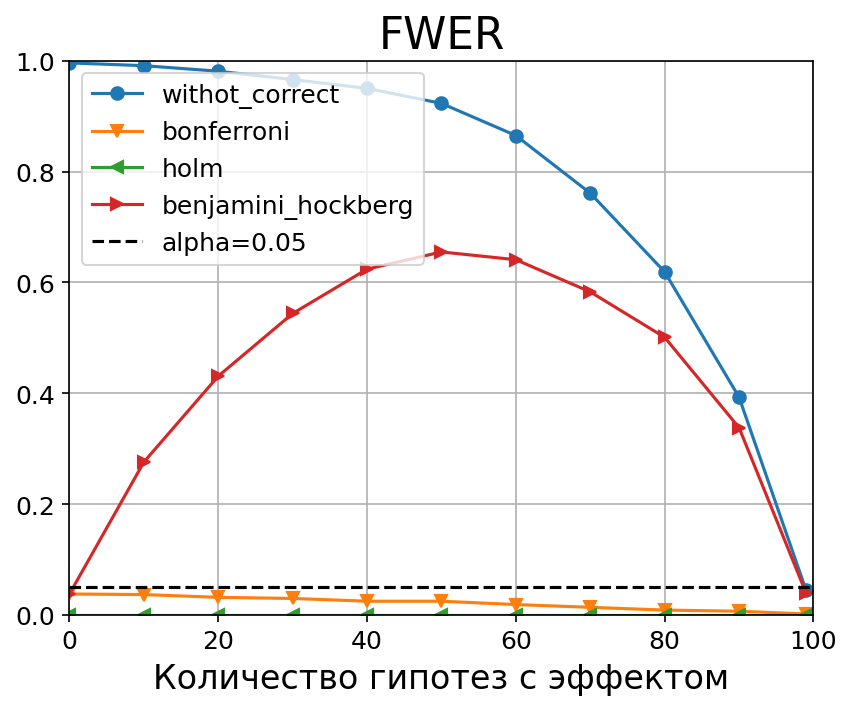

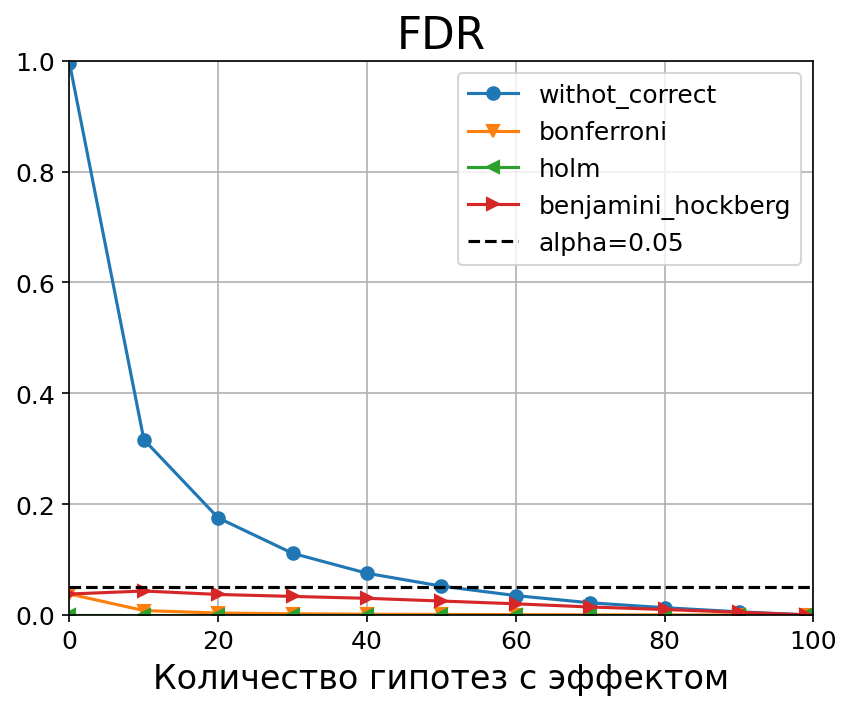

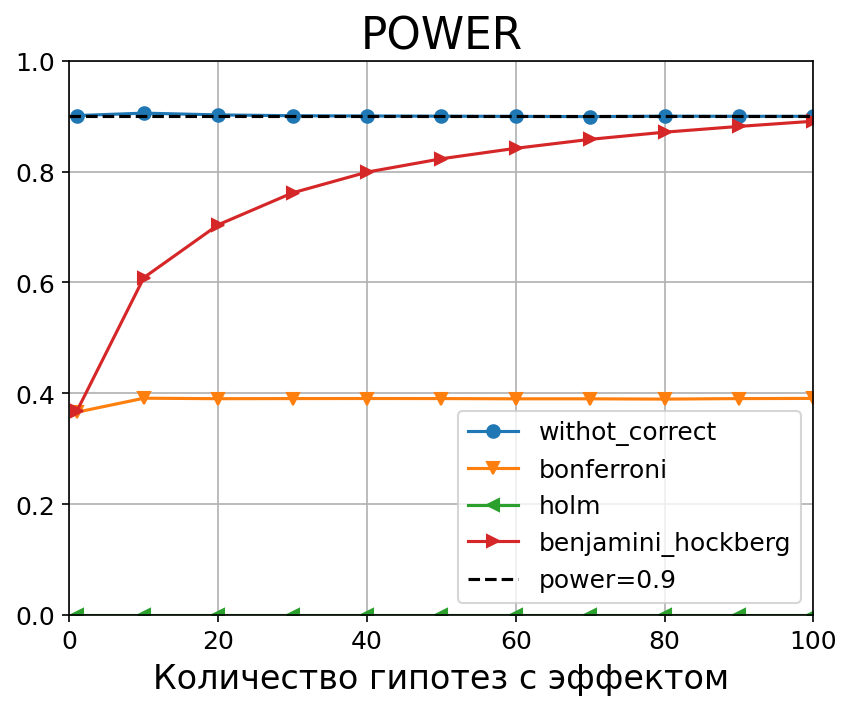

In [ ]:
# Проводим эксперименты
# m - количество проверяемых гипотез
def run(dict_methods, mean, std, sample_size, m, n_iter=1000):
    # разные варианты количества гипотез, в которых есть эффект
    number_with_effect_list = [0, 1] + list(np.arange(10, m, 10)) + [m - 1, m]

    method_to_result = {
        method_name: defaultdict(list) for method_name in dict_methods
    }

    for _ in tqdm(range(n_iter)):
        # Для каждой тестовой используем свою контрольную группу
        control, test = stats.norm(loc=mean, scale=std).rvs((2, m, sample_size))

        prev = 0
        for cur in number_with_effect_list:
            # последовательно добавляем в тестовую группу эффект
            test[prev:cur] += effect
            prev = cur

            pvalues = stats.ttest_ind(control, test, axis=1).pvalue

            for method_name, method in dict_methods.items():
                res = method(pvalues)
                method_to_result[method_name][cur].append({
                    'TP': np.sum(res[:cur] == 1),
                    'FP': np.sum(res[cur:] == 1),
                    'FN': np.sum(res[:cur] == 0),
                    'TN': np.sum(res[cur:] == 0)
                })

    return method_to_result


# Считаем размер выборки
def get_sample_size(effect, std, alpha, beta):
    a = stats.norm().ppf(1 - alpha / 2)
    b = stats.norm().ppf(1 - beta)
    var = 2 * std ** 2 # историческа дисперсия 

    n = np.ceil((var * (a + b) ** 2) / (effect ** 2))
    
    return int(n)

alpha = 0.05            
beta = 0.1                
mean = 1000        # средняя выручка с пользователя в контрольной группе
std = 600                 
effect = 276    
m = 100            # 100 гипотез     

sample_size = get_sample_size(effect, std, alpha, beta)

dict_methods = {
    'withot_correct': method_simple,
    'bonferroni': method_bonferroni,
    'holm': method_holm,
    'benjamini_hockberg': method_benjamini_hochberg
}

method_to_result = run(dict_methods, mean, std, sample_size, m)

plot_metrics(method_to_result, 100, alpha, beta)


New sample size = 215


100%|██████████| 1000/1000 [00:04<00:00, 231.08it/s]


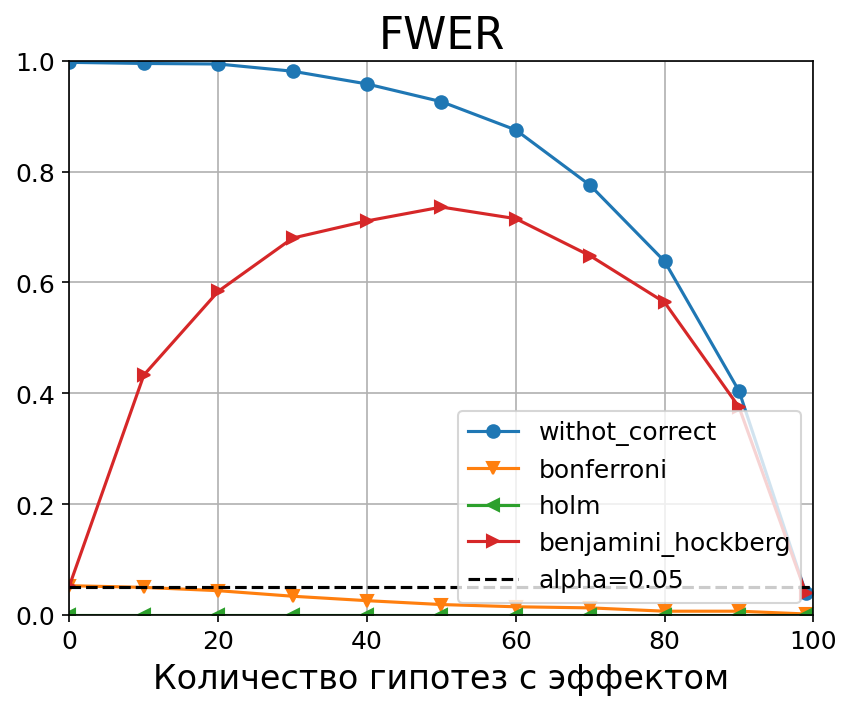

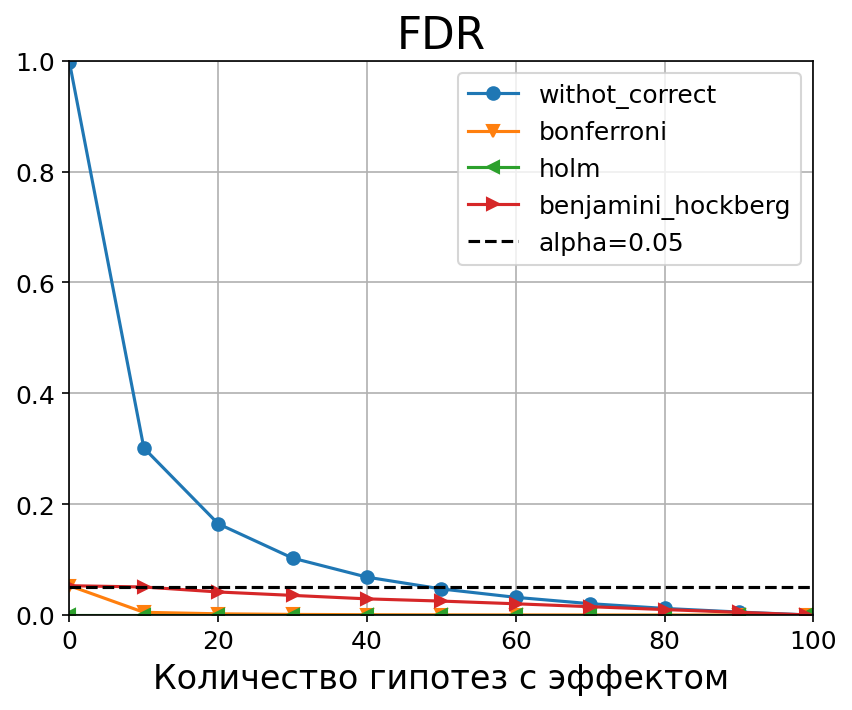

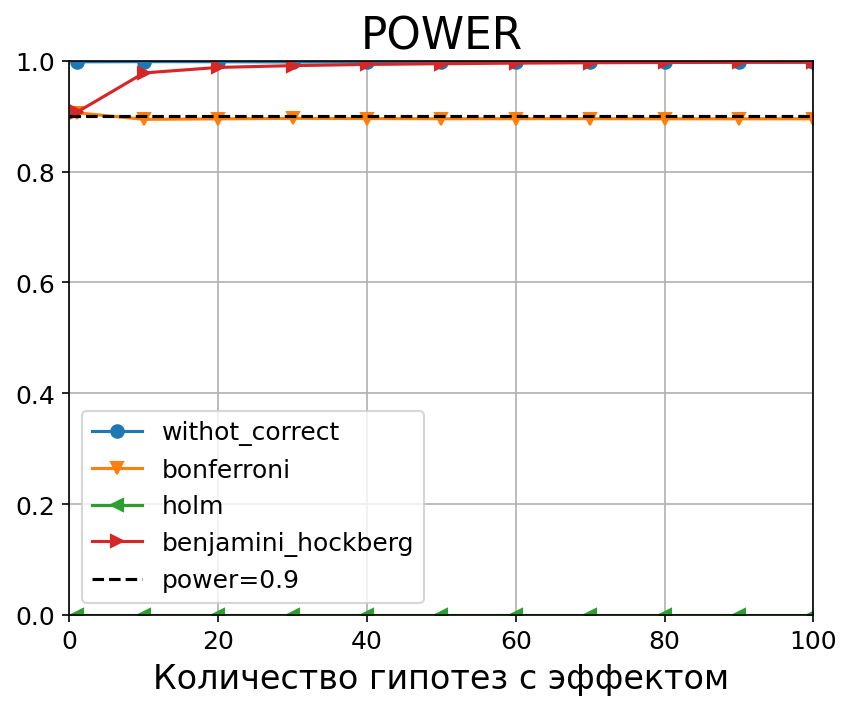

In [22]:
# Чтобы контролировать мощность, используем уровень значимости alpha/m
# в формуле для оценки размера групп

sample_size = get_sample_size(effect, std, alpha/m, beta)
print(f"New sample size = {sample_size}")

method_to_result = run(dict_methods, mean, std, sample_size, m)

plot_metrics(method_to_result, 100, alpha, beta)

**Как уменьшить число пользователей в тестовой группе при множественном тестировании?**

Ранее для каждой тестовой группы мы брали свою контрольную  

Но можно взять общую большую контрольную группу для всех тестовых, чтобы сократить количество пользователей в тестовой группе

Какой выбрать размер групп, чтобы мощность сохранилась на желаемом уровне? Вспомним формулу, связывающую параметры критерия:

$$
\varepsilon^2
=
\left[\Phi^{-1}\!\left(1-\frac{\alpha}{2}\right)+\Phi^{-1}(1-\beta)\right]^2
\left(\frac{\sigma_A^2}{n_A}+\frac{\sigma_B^2}{n_B}\right)
$$

Проверяем $m$ гипотез с объединённой контрольной группой. Положим $n_A = nm$, $n_B = n$ и $\sigma=\sigma_A=\sigma_B$, тогда

$$
n
=
\frac{m+1}{m}\cdot\frac{\sigma^2}{\varepsilon^2}
\left[\Phi^{-1}\!\left(1-\frac{\alpha}{2}\right)+\Phi^{-1}(1-\beta)\right]^2
$$

При $m=1$ получаем $(m+1)/m=2$, а при $m=100$ получаем $(m+1)/m=1.01$.
Ранее размер групп был равен $215$, теперь будем использовать размер групп, равный

$$
\frac{215}{2}\cdot 1.01 \approx 109.
$$

Сократили тестовую группу в два раза!

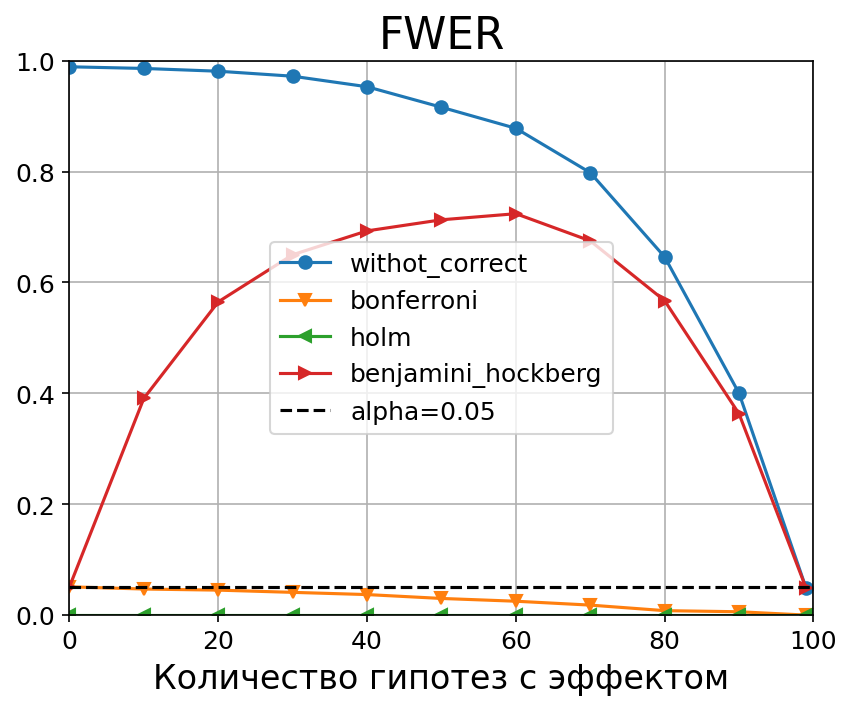

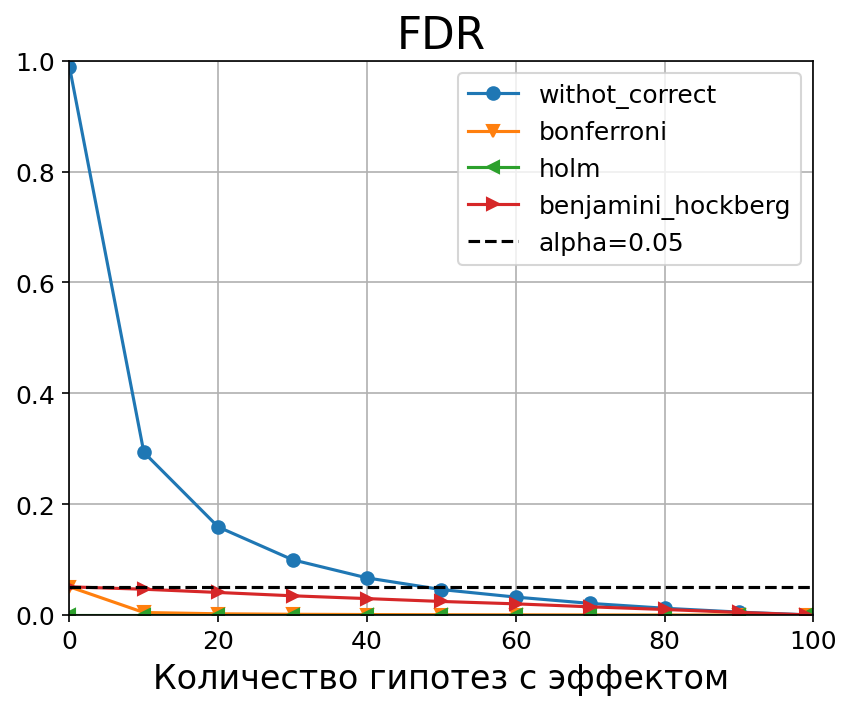

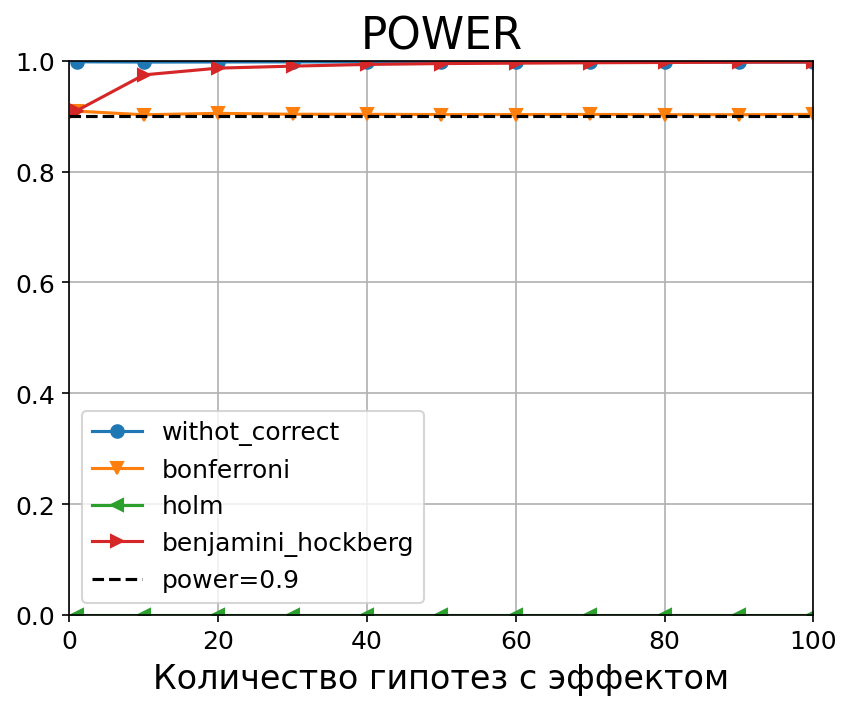

In [26]:
# Можно выбрать оптимальный размер групп, 
# чтобы мощность сохранилась на заданном уровне

sample_size = 109
list_n_exp_with_effect = [0, 1] + list(range(10, m, 10)) + [m-1, m]
method_2_result = {
    method_name: defaultdict(list)
    for method_name in dict_methods
}
for _ in range(1000):
    a_values, b_values = np.random.normal(mean, std, (2, m, sample_size))
    a_values = [a_values.flatten()]
    prev_n_exp_with_effect = 0
    for n_exp_with_effect in list_n_exp_with_effect:
        b_values[prev_n_exp_with_effect: n_exp_with_effect] += effect
        prev_n_exp_with_effect = n_exp_with_effect
        pvalues = stats.ttest_ind(a_values, b_values, axis=1).pvalue
        for method_name, method in dict_methods.items():
            res = method(pvalues)
            method_2_result[method_name][n_exp_with_effect].append({
                'FN': sum(res[:n_exp_with_effect] == 0),
                'TP': sum(res[:n_exp_with_effect] == 1),
                'FP': sum(res[n_exp_with_effect:] == 1),
                'TN': sum(res[n_exp_with_effect:] == 0),
            })
plot_metrics(method_2_result, m)